# Tracking Political Change with Embeddings of Parliamentary Speeches
***
# Test of embeddings

Before using the speech embeddings for our trajectory and event analysis, we test whether they capture politically meaningful structure at all. We cannot judge the quality of the embeddings directly: a 1024-dimensional vector has no inherently correct meaning. Instead, we test whether the embedding geometry aligns with independent, externally known political structures; if it does, that provides evidence that the embeddings encode politically meaningful information rather than just noise or purely superficial linguistic patterns. Specifically, we test whether (1) party membership can be recovered from the embeddings, and (2) the embedding geometry aligns with established external ideology measures such as the Chapel Hill Expert Survey.

In [3]:
# setup
import umap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn as sk
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression, RidgeCV, LinearRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score, adjusted_rand_score, mean_squared_error
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

## 1. Party Affiliation Recovery

To test whether party affiliation is recoverable from the embeddings, we first project the aggregated MP-year embeddings to two dimensions using UMAP for a qualitative visual check, and then apply two quantitative tests: a KMeans clustering, evaluated against the true party labels and a logistic regression classifier trained directly on the full-dimensional embeddings.

In [4]:
# data frame with embedded speeches (off-the-shelf-model) aggregated by MP and year
df_agg_offtheshelf = pd.read_parquet("mp_year_embeddings_offtheshelf.parquet")

# filter out speeches by politicians without fraction as they can't be used to identify parties or ideology
df_agg_offtheshelf = df_agg_offtheshelf[df_agg_offtheshelf.party != "Fraktionslos"]

# stack embeddings into a single 2D array (needed for some methods)
all_embeddings_agg_offtheshelf = np.stack(df_agg_offtheshelf["embedding"])
all_embeddings_agg_offtheshelf.shape

(12434, 1024)

In [5]:
# data frame with embedded speeches (fine-tuned-model) aggregated by MP and year
df_agg_finetuned = pd.read_parquet("mp_year_embeddings_finetuned.parquet")

# filter out speeches by politicians without fraction as they can't be used to identify parties or ideology
df_agg_finetuned = df_agg_finetuned[df_agg_finetuned.party != "Fraktionslos"]

# stack embeddings into a single 2D array (needed for some methods)
all_embeddings_agg_finetuned = np.stack(df_agg_finetuned["embedding"])
all_embeddings_agg_finetuned.shape

(12434, 1024)

### 1.1 Visualization of embeddings using UMAP for dimensionality reduction

First, we apply UMAP dimensionality reduction to visualize embeddings.

In [6]:
party_colors = {
    "CDU/CSU":      "#151518",
    "SPD":          "#E3000F",
    "Grüne":        "#46962B",
    "FDP":          "#FFD700",
    "AfD":          "#009EE0",
    "LINKE":        "#BE3075",
    "PDS":          "#8B4789",
    "Fraktionslos": "#AAAAAA",
}

In [7]:
def plot_umap(embeddings, party_labels, party_colors, title=""):
    """Projects embeddings to 2D with UMAP and plots them colored by party."""
    umap_model = umap.UMAP(n_components=2, metric = 'cosine', random_state=24,)
    embeddings_2d = umap_model.fit_transform(embeddings)

    df_plot = pd.DataFrame({
        "dim1": embeddings_2d[:, 0],
        "dim2": embeddings_2d[:, 1],
        "party": party_labels.values,
    })

    for party, color in party_colors.items():
        subset = df_plot[df_plot["party"] == party]
        plt.scatter(subset["dim1"], subset["dim2"], color=color, label=party, s=3, alpha=0.7)

    plt.legend()
    plt.axis("off")
    plt.title(title)
    plt.show()


#### Off the shelf embeddings

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


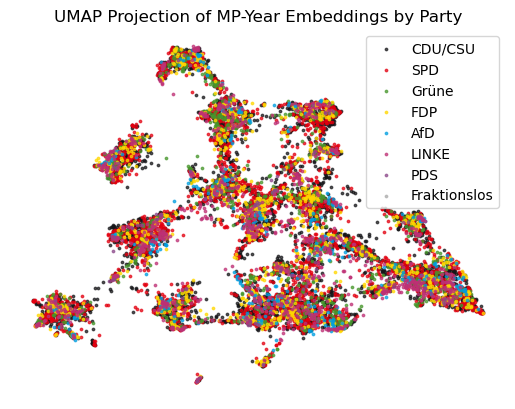

In [8]:
plot_umap(all_embeddings_agg_offtheshelf, df_agg_offtheshelf["party"], party_colors, title="UMAP Projection of MP-Year Embeddings by Party")

#### Fine tuned embeddings

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


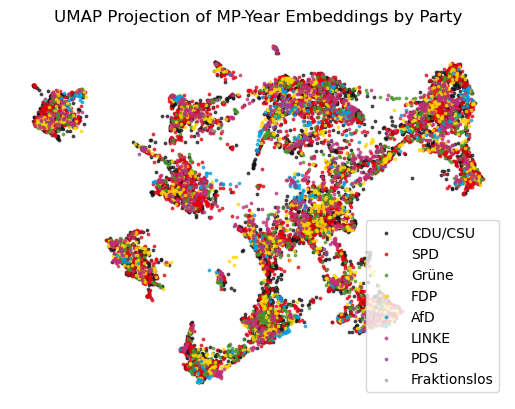

In [9]:
plot_umap(all_embeddings_agg_finetuned, df_agg_finetuned["party"], party_colors, title="UMAP Projection of MP-Year Embeddings by Party")

Neither of the UMAP projections shows visually separable party clusters. This could reflect several factors, e.g. the dominance of topical, stylistic, or procedural variation unrelated to party over ideological signal. It could also simply reflect the loss of information inherent in reducing 1024 dimensions to two. We therefore perform tests directly on the full-dimensional embeddings.

### 1.2 KMeans clustering

We perform KMeans clustering and evaluat it using purity and the Adjusted Rand Index (ARI). 

In [10]:
def evaluate_clustering(embeddings, true_labels):
    """KMeans clustering evaluated against true party labels via purity and ARI."""
    n_clusters = true_labels.nunique()
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=24)
    cluster_labels = kmeans.fit_predict(embeddings)

    df = pd.DataFrame({"cluster": cluster_labels, "true": true_labels.values})
    total = len(df)
    correct = 0
    cluster_to_party = {}
    for cluster_id, group in df.groupby("cluster"):
        majority_label = group["true"].value_counts().idxmax()
        cluster_to_party[cluster_id] = majority_label
        correct += group["true"].value_counts().iloc[0]
    purity = correct / total

    ari = adjusted_rand_score(true_labels, cluster_labels)

    return {
        "purity": purity,
        "ari": ari,
        "cluster_to_party": cluster_to_party,
        "cluster_labels": cluster_labels,
    }


#### Off the shelf embeddings

In [11]:
clustering_results_offtheshelf = evaluate_clustering(all_embeddings_agg_offtheshelf, df_agg_offtheshelf["party"])

print("Cluster-to-party mapping:", clustering_results_offtheshelf["cluster_to_party"])
print("Purity:", clustering_results_offtheshelf["purity"])
print("ARI:", clustering_results_offtheshelf["ari"])

Cluster-to-party mapping: {0: 'CDU/CSU', 1: 'CDU/CSU', 2: 'CDU/CSU', 3: 'CDU/CSU', 4: 'CDU/CSU', 5: 'CDU/CSU', 6: 'CDU/CSU'}
Purity: 0.37212481904455524
ARI: -0.0005999990455931887


#### Fine tuned embeddings

In [12]:
clustering_results_finetuned = evaluate_clustering(all_embeddings_agg_finetuned, df_agg_finetuned["party"])

print("Cluster-to-party mapping:", clustering_results_finetuned["cluster_to_party"])
print("Purity:", clustering_results_finetuned["purity"])
print("ARI:", clustering_results_finetuned["ari"])

Cluster-to-party mapping: {0: 'CDU/CSU', 1: 'CDU/CSU', 2: 'CDU/CSU', 3: 'CDU/CSU', 4: 'CDU/CSU', 5: 'CDU/CSU', 6: 'CDU/CSU'}
Purity: 0.37212481904455524
ARI: -0.0017567011157356696


Purity captures the share of embeddings assigned to the majority class within their respective cluster; however, with imbalanced datasets this measure can be misleading, as it is easy for most or all clusters to end up dominated by the same, largest class, inflating purity without reflecting genuine cluster structure. 

In [13]:
print("Share of speeches per party:")
print(df_agg_offtheshelf["party"].value_counts(normalize=True))

Share of speeches per party:
party
CDU/CSU    0.372125
SPD        0.302879
Grüne      0.103909
FDP        0.096590
LINKE      0.085652
AfD        0.030320
PDS        0.008525
Name: proportion, dtype: float64


Indeed, in both cases all seven clusters are assigned the majority class (CDU/CSU), so purity (0.375) simply reflects CDU/CSU's share of the data rather than genuine separation. We therefore complement it with the ARI, which considers all pairs of data points and checks whether the clustering and the true party labels agree on whether each pair belongs together (i.e., whether points from the same party also end up in the same cluster, and points from different parties end up in different clusters), corrected for the level of agreement expected by chance; our ARIs of -0.0006 and -0.0014 are essentially at chance level.

### 1.3 Logistic regression classifier

Last, we train a logistic regression classifier that uses the embeddings as features.

In [14]:
def evaluate_classifier(embeddings, labels, groups):
    """Logistic regression classifier for party membership, with a grouped train/test split by politician."""
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=24)
    train_idx, test_idx = next(gss.split(embeddings, labels, groups=groups))
    X_train, X_test = embeddings[train_idx], embeddings[test_idx]
    y_train, y_test = labels.iloc[train_idx], labels.iloc[test_idx]

    # baseline: always predict the majority class
    baseline_accuracy = float(y_train.value_counts(normalize=True).max())
    majority_class = y_train.value_counts().idxmax()
    y_pred_baseline = [majority_class] * len(y_test)
    baseline_macro_f1 = f1_score(y_test, y_pred_baseline, average="macro")

    classifier = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=24)
    classifier.fit(X_train, y_train)
    accuracy = classifier.score(X_test, y_test)
    y_pred = classifier.predict(X_test)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    return {
        "baseline_accuracy": baseline_accuracy,
        "baseline_macro_f1": baseline_macro_f1,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
    }

Note: The grouping by politicianId is important: with a random split across all rows, observations from the same politician could end up in both train and test. The classifier could then learn to recognize that individual's writing style or vocabulary rather than a generalizable party signal, artificially inflating accuracy through data leakage, without actually indicating generalization to new, unseen politicians. Using groups ensures that all observations belonging to a given person end up entirely within one of the two sets, never split across both.

#### Off the shelf embeddings

In [15]:
classifier_results_offtheshelf = evaluate_classifier(all_embeddings_agg_offtheshelf, df_agg_offtheshelf["party"], groups=df_agg_offtheshelf["politicianId"])
classifier_results_offtheshelf

{'baseline_accuracy': 0.37079212865847566,
 'baseline_macro_f1': 0.0783189249336643,
 'accuracy': 0.47998349153941394,
 'macro_f1': 0.4624042900424207}

#### Fine tuned embeddings

In [16]:
classifier_results_finetuned = evaluate_classifier(all_embeddings_agg_finetuned, df_agg_finetuned["party"], groups=df_agg_finetuned["politicianId"])
classifier_results_finetuned

{'baseline_accuracy': 0.37079212865847566,
 'baseline_macro_f1': 0.0783189249336643,
 'accuracy': 0.5827486586875774,
 'macro_f1': 0.5430641978318099}

In contrast to the UMAP projections and the KMeans clusterings, the logistic regression classifiers show a clear association between the embeddings and party membership. The classifier trained on the off-the-shelf embeddings achieves an accuracy of 0.480, while the one trained on the fine-tuned embeddings reaches 0.583, both clearly exceeding the majority-class baseline of 0.383. The same pattern holds for macro-F1: 0.462 for the off-the-shelf embeddings and 0.543 for the fine-tuned embeddings, versus a majority-class baseline of only 0.078. This indicates that party membership is recoverable from the embeddings well above chance, and that fine-tuning further improves this recoverability.

## 2. Alignment with External Ideology Measures

In this section, we test whether the embedding geometry aligns with an established, external measure of party ideology (the Chapel Hill Expert Survey's general left-right position, lrgen) by first examining whether any principal component of the embedding space correlates with the scores, and then by training a regressor to predict these scores from the party-year aggregated embeddings.

Before we can do that, we have to add the scores to the data frame with embedded speeches aggregated by party and year.

In [18]:
# data frame with embedded speeches (off-the-shelf-model) aggregated by party and year
df_agg_by_party_offtheshelf = pd.read_parquet("party_year_embeddings_offtheshelf.parquet")

# filter out speeches by politicians without fraction as they can't be used to identify parties or ideology
df_agg_by_party_offtheshelf = df_agg_by_party_offtheshelf[df_agg_by_party_offtheshelf.party != "Fraktionslos"]

In [19]:
# data frame with embedded speeches (fine-tuned-model) aggregated by party and year
df_agg_by_party_finetuned = pd.read_parquet("party_year_embeddings_finetuned.parquet")

# filter out speeches by politicians without fraction as they can't be used to identify parties or ideology
df_agg_by_party_finetuned = df_agg_by_party_finetuned[df_agg_by_party_finetuned.party != "Fraktionslos"]

In [20]:
# Chapel Hill Expert Survey data (already filtered to Germany 1999-2020, with harmonised party names, in notebook 01)
df_ches_relevant = pd.read_csv("ches_de.csv")
df_ches_relevant

,year,party,lrgen
0,1999,CDU/CSU,6.533333
1,1999,DVU,9.769231
2,1999,FDP,6.066667
3,1999,Grüne,3.000000
4,1999,PDS,1.266667
5,1999,REP,9.214286
6,1999,SPD,4.000000
7,2002,CDU/CSU,6.645000
8,2002,FDP,6.070000
9,2002,Grüne,3.360000


In [21]:
# merge data frames (party-year aggregated embeddings and ches scores)
df_agg_ches_scores_offtheshelf = pd.merge_asof(
    df_agg_by_party_offtheshelf.sort_values("year"),
    df_ches_relevant.sort_values("year"),
    on="year",
    by="party",
    direction="backward",
)

df_agg_ches_scores_offtheshelf = df_agg_ches_scores_offtheshelf.dropna(subset=["lrgen"])
df_agg_ches_scores_offtheshelf

,year,party,n_speeches,embedding,lrgen
0,2000,PDS,423,"[0.03871814, -0.097796716, 0.029364387, 0.0011...",1.266667
1,2000,FDP,515,"[0.03787499, -0.09224791, 0.03351736, 0.006683...",6.066667
2,2000,Grüne,473,"[0.048241843, -0.09396336, 0.03288464, 0.01182...",3.000000
3,2000,CDU/CSU,1181,"[0.039275594, -0.09443597, 0.028845197, 0.0078...",6.533333
4,2000,SPD,918,"[0.047752887, -0.087602034, 0.031596202, 0.007...",4.000000
...,...,...,...,...,...
105,2021,FDP,364,"[0.041365884, -0.086701274, 0.048838362, 0.001...",6.428571
106,2021,AfD,371,"[0.044425365, -0.084412046, 0.052488588, -0.00...",9.238095
107,2021,Grüne,326,"[0.04549178, -0.086574174, 0.039026566, -0.002...",3.238095
108,2021,LINKE,325,"[0.032372452, -0.081378765, 0.0374295, -0.0111...",1.428571


In [22]:
# merge data frames (party-year aggregated embeddings and ches scores)
df_agg_ches_scores_finetuned = pd.merge_asof(
    df_agg_by_party_finetuned.sort_values("year"),
    df_ches_relevant.sort_values("year"),
    on="year",
    by="party",
    direction="backward",
)

df_agg_ches_scores_finetuned = df_agg_ches_scores_finetuned.dropna(subset=["lrgen"])
df_agg_ches_scores_finetuned

,year,party,n_speeches,embedding,lrgen
0,2000,PDS,423,"[0.057518236, -0.11475344, 0.048291404, 0.0064...",1.266667
1,2000,FDP,515,"[0.057791818, -0.1095776, 0.052632984, 0.00929...",6.066667
2,2000,Grüne,473,"[0.05993674, -0.10701216, 0.049356274, 0.01011...",3.000000
3,2000,CDU/CSU,1181,"[0.062103026, -0.11075112, 0.051523224, 0.0075...",6.533333
4,2000,SPD,918,"[0.061921015, -0.103271775, 0.048996296, 0.008...",4.000000
...,...,...,...,...,...
105,2021,FDP,364,"[0.06012155, -0.1013837, 0.059034564, 0.008061...",6.428571
106,2021,AfD,371,"[0.06584304, -0.10249603, 0.062310793, 0.00182...",9.238095
107,2021,Grüne,326,"[0.059914622, -0.10074723, 0.052618466, 0.0035...",3.238095
108,2021,LINKE,325,"[0.05161066, -0.09888689, 0.051172145, -0.0008...",1.428571


In [23]:
all_embeddings_agg_by_party_offtheshelf = np.stack(df_agg_ches_scores_offtheshelf["embedding"])
all_embeddings_agg_by_party_offtheshelf.shape

(109, 1024)

In [24]:
all_embeddings_agg_by_party_finetuned = np.stack(df_agg_ches_scores_finetuned["embedding"])
all_embeddings_agg_by_party_finetuned.shape

(109, 1024)

### 2.1 PCA
First, we apply PCA to the party-year aggregated embeddings and check whether any of the resulting principal components correlates with the CHES lrgen scores. 

In [25]:
def evaluate_pca_correlation(embeddings, target, n_components=10):
    """Correlates each of the first n_components principal components with an external target (e.g. lrgen)."""
    pca = PCA(n_components=n_components)
    pcs = pca.fit_transform(embeddings)

    results = []
    for i in range(n_components):
        corr, p = pearsonr(pcs[:, i], target)
        results.append({
            "component": f"PC{i+1}",
            "r": corr,
            "p": p,
            "explained_var": pca.explained_variance_ratio_[i],
        })

    return pd.DataFrame(results), pcs

#### Off the shelf embeddings

In [26]:
pca_results_offtheshelf, pcs_offtheshelf = evaluate_pca_correlation(all_embeddings_agg_by_party_offtheshelf, df_agg_ches_scores_offtheshelf["lrgen"], n_components=10)
pca_results_offtheshelf

,component,r,p,explained_var
0,PC1,-0.125211,0.194536,0.245835
1,PC2,-0.327687,0.000505,0.152414
2,PC3,0.335903,0.000356,0.098698
3,PC4,-0.321521,0.000652,0.076741
4,PC5,0.128595,0.182652,0.066753
5,PC6,0.060032,0.535200,0.048471
6,PC7,0.107585,0.265490,0.041866
7,PC8,0.435161,0.000002,0.032105
8,PC9,-0.302225,0.001403,0.026224
9,PC10,0.398334,0.000018,0.022402


The correlation between PC1 and lrgen is weak and not statistically significant (r = -0.125, p = 0.19); note that only the magnitude of the correlation is meaningful here, since PCA does not fix the sign or direction of a component.

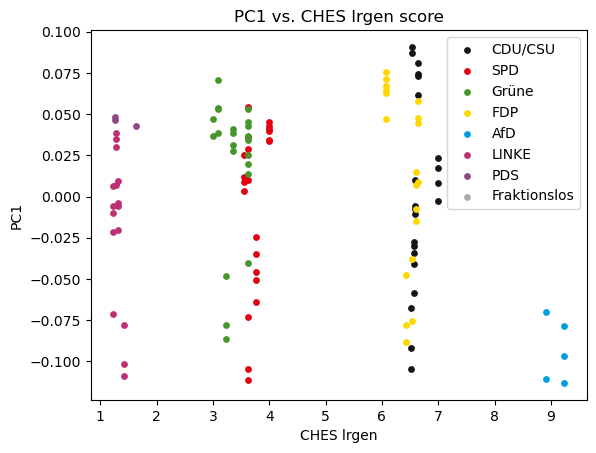

In [27]:
# plot ches scores vs. PC1
for party, color in party_colors.items():
    mask = df_agg_ches_scores_offtheshelf["party"] == party
    plt.scatter(df_agg_ches_scores_offtheshelf.loc[mask, "lrgen"], pcs_offtheshelf[mask.values, 0],
                color=color, label=party, s=15)

plt.xlabel("CHES lrgen")
plt.ylabel("PC1")
plt.legend()
plt.title("PC1 vs. CHES lrgen score")
plt.show()

PC1 shows a weak ordering effect: the centrist-to-mainstream parties (Grüne, SPD, CDU/CSU, FDP) and LINKE each span nearly the entire range of PC1 values, overlapping heavily with one another, and the more extreme parties (PDS, AfD) fall within this same broad range, only shifted toward one end (PDS near the top, AfD near the bottom) rather than being clearly separated.

Since the ideological signal may not be captured by the direction of maximum overall variance, we extend the analysis to the first ten principal components to check whether a later, less dominant component correlates more strongly with lrgen.

Several components show statistically significant correlations with lrgen (e.g. PC2, PC3, PC4, PC8, PC9, PC10), with PC8 showing the strongest relationship (r = 0.435, p < 0.001), even though it explains only 3.2% of the total variance, suggesting that ideological information, while present, is distributed across several secondary directions rather than concentrated in the dominant axis of variation.

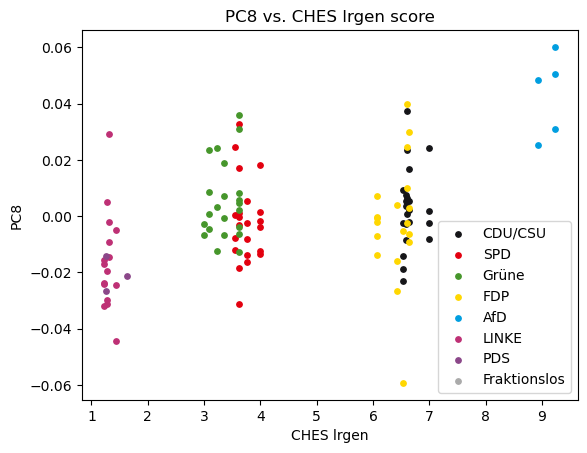

In [28]:
# plot ches scores vs. PC8 (strongest correlation)

for party, color in party_colors.items():
    mask = df_agg_ches_scores_offtheshelf["party"] == party
    plt.scatter(df_agg_ches_scores_offtheshelf.loc[mask, "lrgen"], pcs_offtheshelf[mask.values, 7],
                color=color, label=party, s=15)

plt.xlabel("CHES lrgen")
plt.ylabel("PC8")
plt.legend(loc="lower right")
plt.title("PC8 vs. CHES lrgen score")
plt.show()

PC8 shows a somewhat cleaner pattern than PC1: the mainstream parties still overlap substantially with each other and remain indistinguishable among themselves, but they now form a more compact group that is more clearly separated from the extremes, with LINKE/PDS positioned toward the lower end and AfD clearly and consistently at the upper end. In neither component, however, is there any separation among the mainstream parties themselves; the correlation with lrgen in both cases appears to be driven primarily by the extreme parties, not by a consistent ordering across the full ideological spectrum.

#### Fine tuned embeddings

In [29]:
pca_results_finetuned, pcs_finetuned = evaluate_pca_correlation(all_embeddings_agg_by_party_finetuned, df_agg_ches_scores_finetuned["lrgen"], n_components=10)
pca_results_finetuned

,component,r,p,explained_var
0,PC1,0.096043,3.204852e-01,0.352615
1,PC2,0.367267,8.552280e-05,0.135891
2,PC3,0.204619,3.281843e-02,0.110081
3,PC4,-0.497685,3.673933e-08,0.077345
4,PC5,0.192072,4.540980e-02,0.060988
5,PC6,-0.160736,9.498678e-02,0.047402
6,PC7,-0.138673,1.504189e-01,0.032889
7,PC8,-0.249568,8.868686e-03,0.027929
8,PC9,-0.437505,1.964358e-06,0.022879
9,PC10,0.052696,5.863025e-01,0.019330


The correlation between PC1 and lrgen is even weaker than for the off the shelf embeddings and not statistically significant (r = 0.096, p = 0.32).

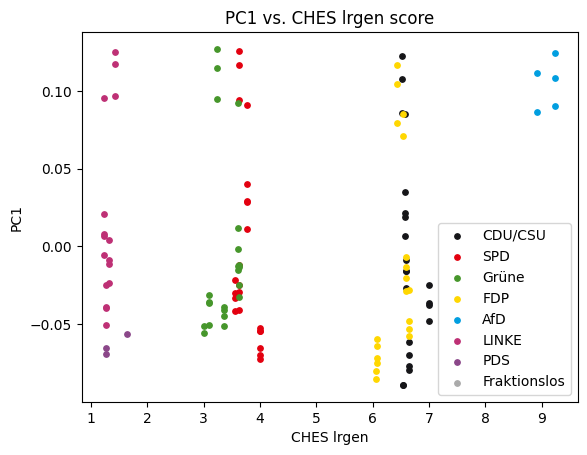

In [30]:
# plot ches scores vs. PC1
for party, color in party_colors.items():
    mask = df_agg_ches_scores_finetuned["party"] == party
    plt.scatter(df_agg_ches_scores_finetuned.loc[mask, "lrgen"], pcs_finetuned[mask.values, 0],
                color=color, label=party, s=15)

plt.xlabel("CHES lrgen")
plt.ylabel("PC1")
plt.legend()
plt.title("PC1 vs. CHES lrgen score")
plt.show()

For the fine-tuned embeddings, PC1 shows essentially the same pattern as for the off-the-shelf embeddings, only with the direction reversed: AfD now falls near the top and PDS near the bottom of the PC1 range. As before, however, the other parties (Grüne, SPD, CDU/CSU, LINKE, FDP) each span nearly the entire range of values, and AfD and PDS remain within this same broad range rather than being clearly separated from it.

Several later components are strongly significant, most notably PC4 (r = -0.498, p < 0.001), which explains 7.7% of the total variance; a somewhat stronger correlation than the strongest component found for the off-the-shelf embeddings (PC8, r = 0.435), though both remain in a similar, moderate range.

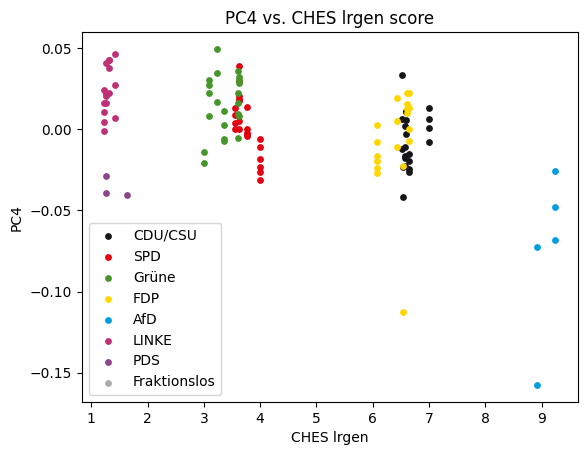

In [31]:
# plot ches scores vs. PC4 (strongest correlation)

for party, color in party_colors.items():
    mask = df_agg_ches_scores_finetuned["party"] == party
    plt.scatter(df_agg_ches_scores_finetuned.loc[mask, "lrgen"], pcs_finetuned[mask.values, 3],
                color=color, label=party, s=15)

plt.xlabel("CHES lrgen")
plt.ylabel("PC4")
plt.legend(loc="lower left")
plt.title("PC4 vs. CHES lrgen score")
plt.show()

LINKE is clearly positioned at the top of the PC4 range. Among the centrist parties, a weak tendency is visible: Grüne tends to score highest, followed by SPD, with CDU/CSU and FDP clustering lowest among this group,though overlap between them remains substantial. AfD is clearly separated at the bottom of the range. The only party that clearly doens't fit the true lr scale is the left party PDS which has similar PC4 scores as the right wing party AfD.

Given this mixed evidence, we next turn to a supervised regression approach to test more directly whether the embeddings can predict ideological position.

### 2.2 Ridge Regression

Since the number of features (1024) far exceeds the number of observations, ordinary least squares would be severely underdetermined, leading to overfitting. Therefore, we use Ridge regression, which addresses this problem through regularization. 

The alpha parameter controls the strength of this regularization, with larger values shrinking coefficients more aggressively. We select alpha via cross-validation (RidgeCV) over a logarithmically spaced grid of candidate values.

In [32]:
def split_grouped(embeddings, target, groups, test_size=0.2):
    """Grouped train/test split so that all observations of one group (e.g. party) stay together."""
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=24)
    train_idx, test_idx = next(gss.split(embeddings, target, groups=groups))
    X_train, X_test = embeddings[train_idx], embeddings[test_idx]
    y_train, y_test = target.iloc[train_idx], target.iloc[test_idx]
    return X_train, X_test, y_train, y_test


def evaluate_ridge(X_train, X_test, y_train, y_test):
    """Ridge regression predicting an external target (e.g. lrgen) from embeddings."""
    regressor = RidgeCV(alphas=np.logspace(-2, 4, 20))
    regressor.fit(X_train, y_train)
    y_pred = regressor.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    baseline_pred = y_train.mean()
    baseline_mse = mean_squared_error(y_test, [baseline_pred] * len(y_test))
    r2 = regressor.score(X_test, y_test)
    corr, p = pearsonr(y_pred, y_test)
    corr, p = float(corr), float(p)

    return {
        "mse": mse,
        "baseline_mse": baseline_mse,
        "r2": r2,
        "correlation": corr,
        "p_value": p,
    }


def evaluate_pcr(X_train, X_test, y_train, y_test, n_components=15):
    """Principal Component Regression as a robustness check for the Ridge regression above."""
    pca = PCA(n_components=n_components)
    X_train_pcr = pca.fit_transform(X_train)
    X_test_pcr = pca.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_pcr, y_train)
    y_pred = model.predict(X_test_pcr)

    mse = mean_squared_error(y_test, y_pred)
    r2 = model.score(X_test_pcr, y_test)
    corr, p = pearsonr(y_pred, y_test)
    corr, p = float(corr), float(p)

    return {"mse": mse, "r2": r2, "correlation": corr, "p_value": p}

Note: As with the classifier, we use a grouped split (this time grouping by party rather than by politician) to ensure that all years of a given party fall entirely within either the training or the test set. Without this, the regressor could effectively memorize a party's approximate ideological position from other years of the same party rather than learning a relationship that generalizes to unseen parties.

#### Off the shelf embeddings

In [33]:
X_train_reg_offtheshelf, X_test_reg_offtheshelf, y_train_reg_offtheshelf, y_test_reg_offtheshelf = split_grouped(
    all_embeddings_agg_by_party_offtheshelf, df_agg_ches_scores_offtheshelf["lrgen"], groups=df_agg_ches_scores_offtheshelf["party"]
)

ridge_results_offtheshelf = evaluate_ridge(X_train_reg_offtheshelf, X_test_reg_offtheshelf, y_train_reg_offtheshelf, y_test_reg_offtheshelf)
ridge_results_offtheshelf

{'mse': 9.440701483129901,
 'baseline_mse': 9.357037659716182,
 'r2': -5.381451467985436,
 'correlation': 0.3144875051722671,
 'p_value': 0.05448268648217435}

The MSE (9.44) is even slightly worse than the naive baseline of predicting the training mean (9.36), and the negative R² (-5.38) confirms that the model performs far worse than a simple constant prediction. The correlation between predicted and true values, however, is moderate and correctly signed (r = 0.314), falling just short of significance at the 5% level (p = 0.054)

#### Fine tuned embeddings

In [34]:
X_train_reg_finetuned, X_test_reg_finetuned, y_train_reg_finetuned, y_test_reg_finetuned = split_grouped(
    all_embeddings_agg_by_party_finetuned, df_agg_ches_scores_finetuned["lrgen"], groups=df_agg_ches_scores_finetuned["party"]
)

ridge_results_finetuned = evaluate_ridge(X_train_reg_finetuned, X_test_reg_finetuned, y_train_reg_finetuned, y_test_reg_finetuned)
ridge_results_finetuned

{'mse': 9.232465524529943,
 'baseline_mse': 9.357037659716182,
 'r2': -5.240694166627094,
 'correlation': 0.4586260051313676,
 'p_value': 0.003780226375718294}

For the fine-tuned embeddings, the same pattern emerges but more pronounced: MSE (9.23) and R² (-5.24) remain poor, similar to the off-the-shelf embeddings. The correlation between predicted and true values, however, is now moderate-to-strong and statistically significant (r = 0.459, p = 0.004). This is a clearer signal than for the off-the-shelf embeddings, suggesting that fine-tuning strengthens the (still incomplete) ideological signal recoverable via regression.

### 2.3 Principal Component Regression

As a robustness check, we also fit a Principal Component Regression, using the first 15 principal components as predictors for an ordinary linear regression. This provides an alternative way of handling the high dimensionality relative to the number of observations, allowing us to check whether the poor predictive performance is specific to Ridge regression or reflects a more general absence of linearly recoverable ideological signal.

#### Off the shelf embeddings

In [35]:
pcr_results_offtheshelf = evaluate_pcr(X_train_reg_offtheshelf, X_test_reg_offtheshelf, y_train_reg_offtheshelf, y_test_reg_offtheshelf, n_components=15)
pcr_results_offtheshelf

{'mse': 9.62421717236704,
 'r2': -5.5054990789149185,
 'correlation': 0.11337440766627384,
 'p_value': 0.49794247405628206}

Principal Component Regression yields metrics broadly consistent with Ridge regression: MSE (9.62) and R² (-5.50) remain similarly poor. The correlation between predicted and true values is weaker but still correctly signed for PCR (r = 0.114), and it is now statistically insignificant (p = 0.50). 

#### Fine tuned embeddings

In [36]:
pcr_results_finetuned = evaluate_pcr(X_train_reg_finetuned, X_test_reg_finetuned, y_train_reg_finetuned, y_test_reg_finetuned, n_components=15)
pcr_results_finetuned

{'mse': 10.628990859669274,
 'r2': -6.184676842695056,
 'correlation': 0.22121973610575887,
 'p_value': 0.18196074011360855}

For the fine-tuned embeddings, PCR performs somewhat worse than for the off-the-shelf embeddings: MSE (10.63) and R² (-6.18) are both slightly higher (i.e. worse), and the correlation between predicted and true values, while still correctly signed (r = 0.222), remains statistically insignificant (p = 0.181). This contrasts with the Ridge regression results above, where fine-tuning improved the correlation, so the benefit of fine-tuning for ideological prediction is not consistent across regression methods.